# Logit model

Suppose we are interested in predicting the probability of delisting of a stock due to either:
- Bankrupt
- Liquidation

as function of its size. 

We use two models:
1. OLS
2. Logit model

## 0. Required packages

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

## 1. Load and prepare data

We use data from Compustat. Delisting is stored as categorical variable `dlrsn`. Bankrupt and liquidation are coded as "02" and "03".

We create a balanced sample of delisted and active firms. In other words we randomly sample firms that delist due to bankrupt or liquidation and firms that do not in the next five years. 

Disclaimer: this may be seen as "cherry-picking". In fact, there is relative little variation in the sample for delisting firms. 

In [3]:
df = pd.read_csv("Delisting.csv", parse_dates=["datadate", "dldte"])

# Keep observations that are before deletion date (or never deleted)
df = df[df["dldte"].isna() | (df["datadate"] < df["dldte"])].copy()

# Clean deletion reason codes to 2-digit strings: "1" -> "01"
df["dlrsn"] = df["dlrsn"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(2)

# ----------------------------
# Define an event that is "distress-like"
# Bankruptcy / liquidation are common choices for a clear classroom example.
# (You can change these codes if your Compustat manual for your extract differs.)
# ----------------------------
FAIL_CODES = {"02", "03"}  # bankruptcy, liquidation

days_to_del = (df["dldte"] - df["datadate"]).dt.days
df["FAIL_1Y"] = ((days_to_del >= 1) & (days_to_del <= 365) & (df["dlrsn"].isin(FAIL_CODES))).astype(int)

# Clean control group: survives at least 5 years from datadate (no deletion soon)
df["SURV_5Y"] = (df["dldte"].isna() | ((df["dldte"] - df["datadate"]).dt.days > 5 * 365)).astype(int)

df = df[df['atq'] > 0]
df["X"] = np.log(df["atq"])  # SIZE


use_all = df[["FAIL_1Y", "SURV_5Y", "X"]].replace([np.inf, -np.inf], np.nan).dropna()

# Trim extreme X to make the plot readable
x_lo, x_hi = use_all["X"].quantile([0.001, 0.999])

use_all = use_all[(use_all["X"] >= x_lo) & (use_all["X"] <= x_hi)].copy()

# ----------------------------
# balanced sample
# ----------------------------
events = use_all[use_all["FAIL_1Y"] == 1]
controls = use_all[(use_all["FAIL_1Y"] == 0) & (use_all["SURV_5Y"] == 1)]

n = len(events)
if n == 0:
    raise ValueError("No failure events found under your FAIL_CODES/window. Check dlrsn codes and dldte coverage.")
if len(controls) < n:
    controls_s = controls.sample(n=len(controls), random_state=0)
    events_s = events.sample(n=len(controls), random_state=0)
else:
    controls_s = controls.sample(n=n, random_state=0)
    events_s = events

use = pd.concat([events_s, controls_s], axis=0).sample(frac=1, random_state=1)  # shuffle


## 2. Estimate the model

The logit model reads as:

$$
p(X) = \frac{e^{\beta_0 + \beta_1 x_i}}{1+ e^{\beta_0 + \beta_1 x_i}}
$$

Additionally, we employ an OLS model for comparability.

The logit model can be estimate by Maximum Likelihood through the `statsmodels` package using `sm.Logit`, which includes the subfunction `fit()` (as we did for OLS).

Furthermore, recall that the logit fits a non-linear model: the interpretation of the coefficients must account for that. Thus we estimate:
- Average marginal effect (AME)
- Marginal effect at the mean (MEM)

Both can be estimated within the `Logit` function by calling `get_margeff` with argument `at` equal to `overall` and `mean` for AME and MEM, respectively.

In [4]:

y = use["FAIL_1Y"].astype(float)
X = sm.add_constant(use[["X"]])

# OLS linear probability model
ols = sm.OLS(y, X).fit(cov_type="HC1")

# Logit
logit = sm.Logit(y, X).fit(disp=0)

print("\nBalanced sample event rate:", np.round(y.mean(), 3), "N:", len(use))
print("\n=== OLS (LPM) ===")
print(ols.summary())
print("\n=== Logit ===")
print(logit.summary())

# Predictions on a grid
x_grid = np.linspace(use["X"].min(), use["X"].max(), 400)
Xg = sm.add_constant(pd.DataFrame({"X": x_grid}))
p_ols = ols.predict(Xg)
p_log = logit.predict(Xg)

ame = logit.get_margeff(at='overall')  # AME
mem = logit.get_margeff(at='mean')  # MEM

print(ame.summary())
print(mem.summary())


# Show how OLS violates [0,1] on the grid
print("\nOLS p-hat on grid: min =", float(p_ols.min()), "max =", float(p_ols.max()))
print("Share of grid with p<0 or p>1:", float(((p_ols < 0) | (p_ols > 1)).mean()))



Balanced sample event rate: 0.5 N: 3160

=== OLS (LPM) ===
                            OLS Regression Results                            
Dep. Variable:                FAIL_1Y   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     277.3
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           9.35e-60
Time:                        10:55:32   Log-Likelihood:                -2165.5
No. Observations:                3160   AIC:                             4335.
Df Residuals:                    3158   BIC:                             4347.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

## 3. Plot

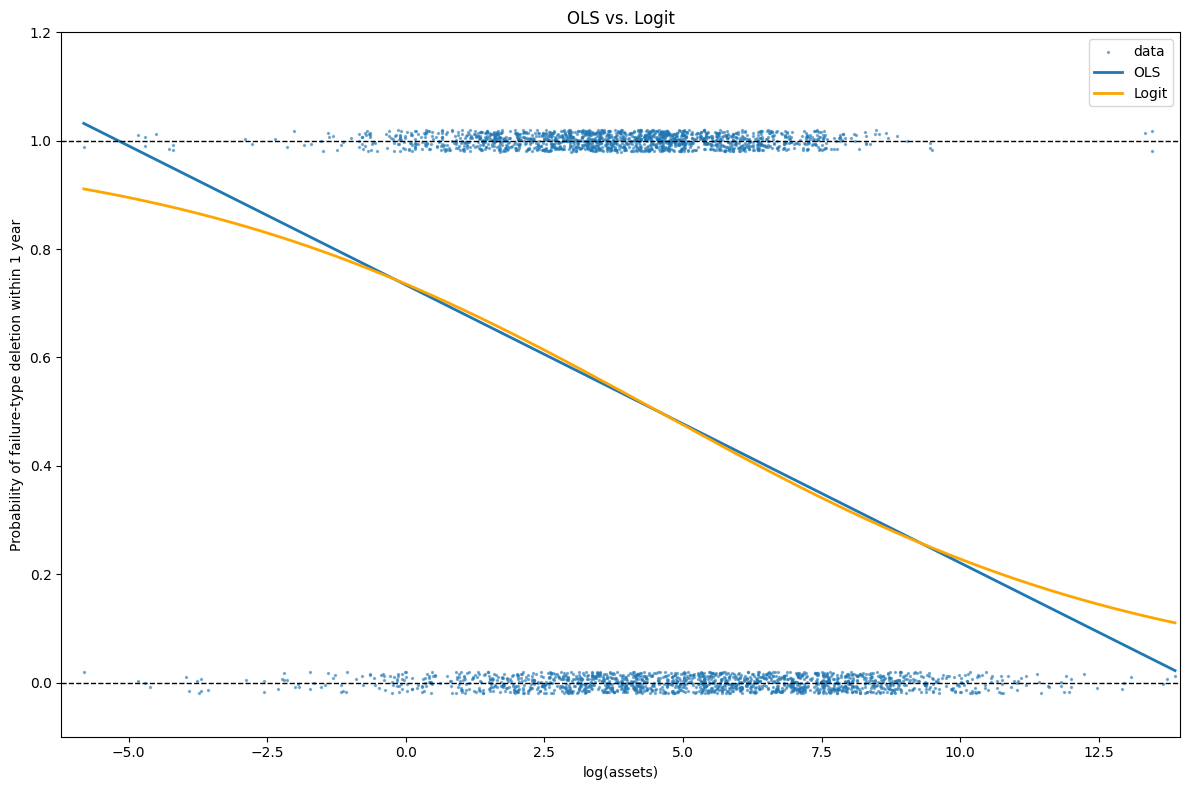

In [5]:
rng = np.random.default_rng(0)
n_show = min(20000, len(use))
idx = rng.choice(use.index.to_numpy(), size=n_show, replace=False)
jitter = rng.uniform(-0.02, 0.02, size=n_show)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.scatter(use.loc[idx, "X"], use.loc[idx, "FAIL_1Y"] + jitter, s=2, alpha=0.5, label='data')
ax.plot(x_grid, p_ols, linewidth=2, label='OLS')
ax.plot(x_grid, p_log, linewidth=2, color='orange', label='Logit')

ax.axhline(0, linestyle="--", linewidth=1, color='black')
ax.axhline(1, linestyle="--", linewidth=1, color='black')
ax.set_title("OLS vs. Logit")
ax.set_xlabel("log(assets)")
ax.set_ylabel("Probability of failure-type deletion within 1 year")
ax.set_ylim(-0.1, 1.2)
ax.set_xlim([x_lo, x_hi])
plt.legend()
plt.tight_layout()
plt.show()